
MÉDIAS DAS MÉTRICAS POR TAXA DE FALHA (média entre links)

--- RMSE ---
Stacking         -> 20%: 117.7220 | 30%: 112.8460 | 40%: 149.0540 | 50%: 189.7020
Mediana          -> 20%: 605.0100 | 30%: 628.3200 | 40%: 659.8920 | 50%: 658.9940
KNN              -> 20%: 615.9240 | 30%: 625.0020 | 40%: 642.6500 | 50%: 644.1480
F.Fill           -> 20%: 513.7600 | 30%: 506.9780 | 40%: 506.0340 | 50%: 526.6300
B.Fill           -> 20%: 462.8100 | 30%: 496.3020 | 40%: 498.0260 | 50%: 504.4260
Interp. Linear   -> 20%: 406.2920 | 30%: 428.3000 | 40%: 434.9800 | 50%: 445.9300

--- NRMSE ---
Stacking         -> 20%: 4.8560 | 30%: 5.9480 | 40%: 6.5240 | 50%: 9.5820
Mediana          -> 20%: 17.2440 | 30%: 20.6860 | 40%: 24.3140 | 50%: 24.2480
KNN              -> 20%: 18.5280 | 30%: 20.1160 | 40%: 22.7000 | 50%: 22.7920
F.Fill           -> 20%: 16.1140 | 30%: 16.9960 | 40%: 17.7800 | 50%: 19.5460
B.Fill           -> 20%: 13.5160 | 30%: 16.7440 | 40%: 20.0760 | 50%: 20.7440
Interp. Linear   -> 20%: 11.8340 |

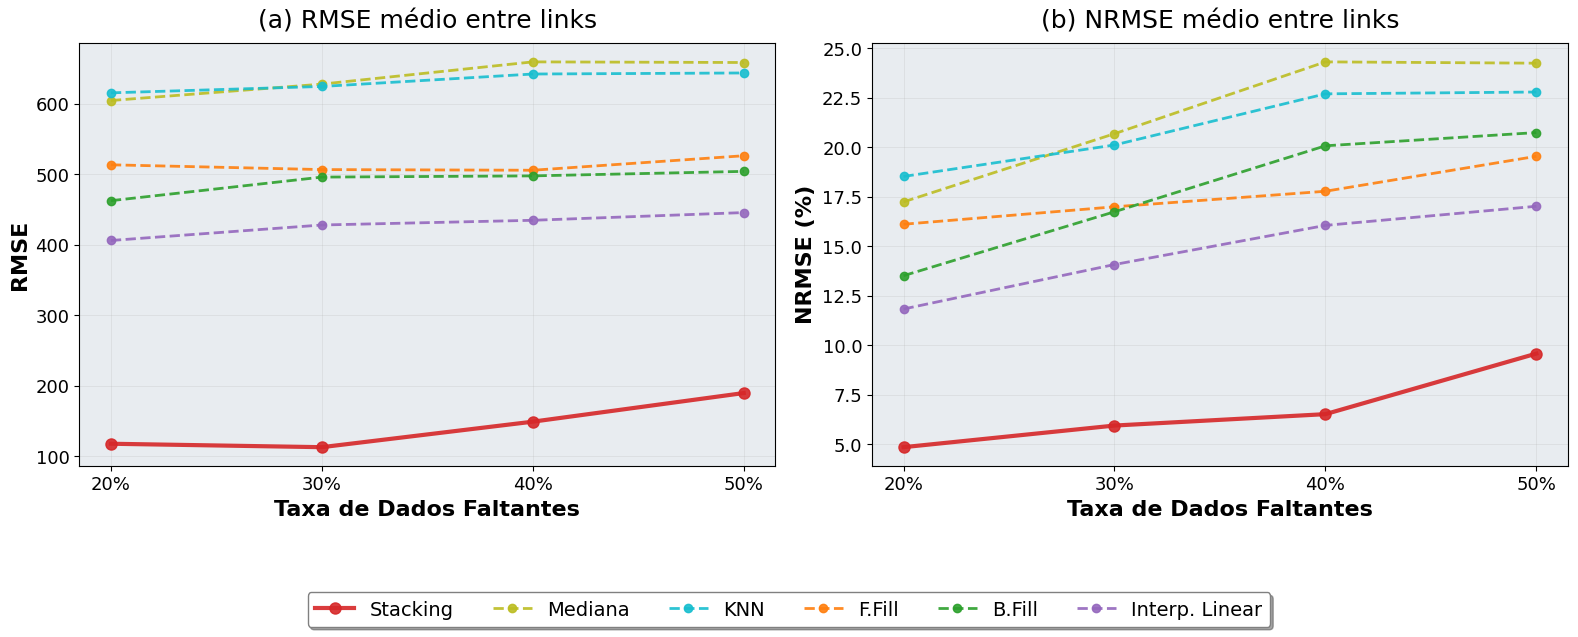

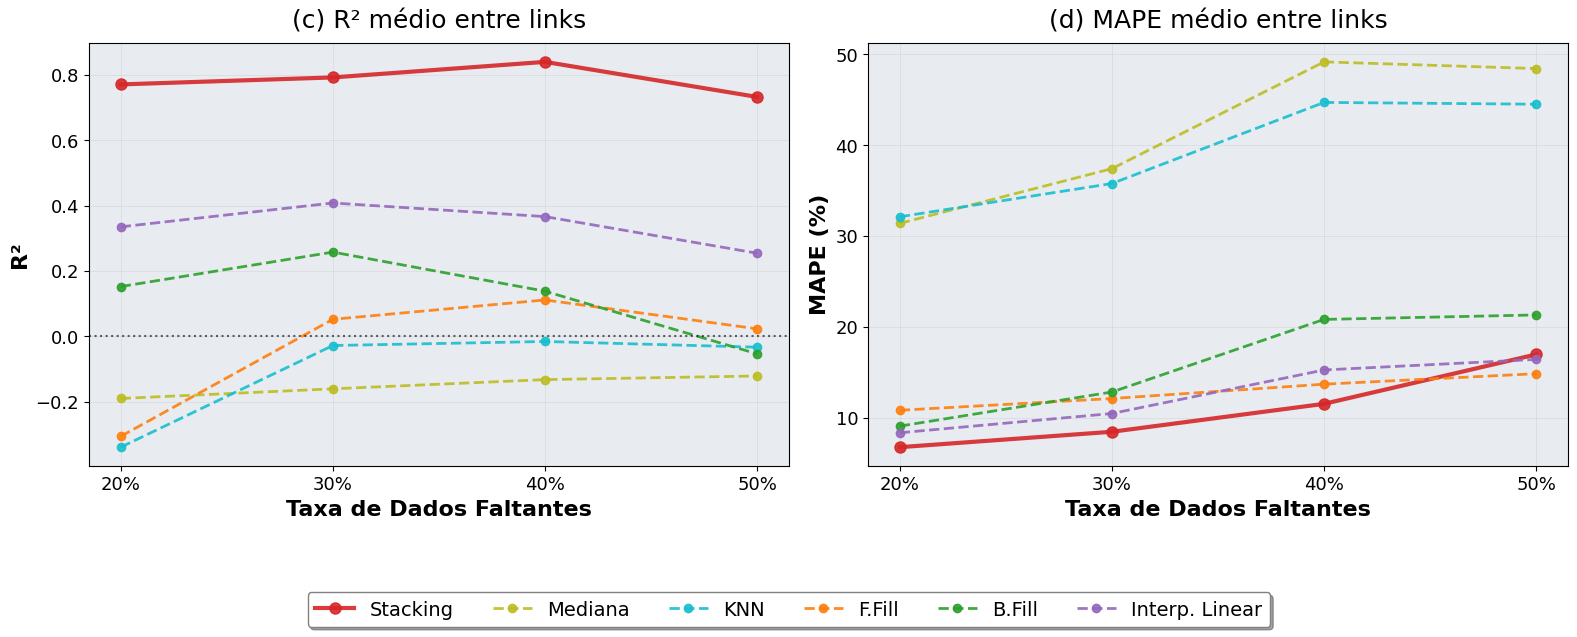

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# =========================
# CONFIG
# =========================
JSON_PATH = "../results/metrics_summary.json"

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.size"] = 14
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["xtick.labelsize"] = 13
plt.rcParams["ytick.labelsize"] = 13

missing_rates_order = ["0.2", "0.3", "0.4", "0.5"]
missing_rates_labels = ["20%", "30%", "40%", "50%"]

# Só os métodos que você quer manter
method_name_map = {
    "Median": "Mediana",
    "KNNImputer": "KNN",
    "ForwardFill": "F.Fill",
    "BackwardFill": "B.Fill",
    "LinearInterpolation": "Interp. Linear",
    "StackingRegressor": "Stacking",
}

preferred_order = [
    "Stacking",
    "Mediana",
    "KNN",
    "F.Fill",
    "B.Fill",
    "Interp. Linear",
]

colors = {
    "Stacking": "#d62728",
    "Mediana": "#bcbd22",
    "KNN": "#17becf",
    "F.Fill": "#ff7f0e",
    "B.Fill": "#2ca02c",
    "Interp. Linear": "#9467bd",
}

metrics_to_plot = ["rmse", "nrmse", "r2", "mape"]


# =========================
# LEITURA
# =========================
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def safe_append(container, key1, key2, value):
    if value is not None:
        container[key1][key2].append(value)


# =========================
# AGREGAÇÃO
# =========================
def aggregate_metrics_mean(data):
    """
    aggregated[metric][method] = [media_20, media_30, media_40, media_50]
    """
    temp = {metric: defaultdict(lambda: defaultdict(list)) for metric in metrics_to_plot}

    for link_name, link_data in data.items():
        for missing_rate, missing_data in link_data.items():

            # -------- baseline --------
            baseline = missing_data.get("baseline", {})
            for raw_method, metric_values in baseline.items():
                # IGNORA qualquer método que não esteja explicitamente permitido
                if raw_method not in method_name_map:
                    continue

                method = method_name_map[raw_method]

                for metric in metrics_to_plot:
                    value = metric_values.get(metric)
                    safe_append(temp[metric], missing_rate, method, value)

            # -------- stacking --------
            stacking = missing_data.get("stacking", {})
            for stack_group_name, stack_group in stacking.items():
                for raw_method, metric_values in stack_group.items():
                    # IGNORA qualquer método que não esteja explicitamente permitido
                    if raw_method not in method_name_map:
                        continue

                    method = method_name_map[raw_method]

                    for metric in metrics_to_plot:
                        value = metric_values.get(metric)
                        safe_append(temp[metric], missing_rate, method, value)

    aggregated = {metric: {} for metric in metrics_to_plot}

    for metric in metrics_to_plot:
        for method in preferred_order:
            values_by_rate = []
            has_any_value = False

            for mr in missing_rates_order:
                vals = temp[metric][mr].get(method, [])
                if vals:
                    values_by_rate.append(float(np.mean(vals)))
                    has_any_value = True
                else:
                    values_by_rate.append(np.nan)

            if has_any_value:
                aggregated[metric][method] = values_by_rate

    return aggregated


# =========================
# PLOT
# =========================
def plot_two_metrics(metric1_data, metric2_data, ylabel1, ylabel2, title1, title2, outname):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, data, ylabel, title in zip(
        axes,
        [metric1_data, metric2_data],
        [ylabel1, ylabel2],
        [title1, title2]
    ):
        for method in preferred_order:
            if method not in data:
                continue

            y = data[method]
            linestyle = "-" if method == "Stacking" else "--"
            linewidth = 3 if method == "Stacking" else 2
            markersize = 8 if method == "Stacking" else 6

            ax.plot(
                missing_rates_labels,
                y,
                marker="o",
                linestyle=linestyle,
                linewidth=linewidth,
                markersize=markersize,
                label=method,
                color=colors.get(method),
                alpha=0.9,
            )

        ax.set_xlabel("Taxa de Dados Faltantes", fontweight="bold")
        ax.set_ylabel(ylabel, fontweight="bold")
        ax.set_title(title, pad=10)
        ax.grid(True, alpha=0.3, linestyle="-", linewidth=0.5)
        ax.set_facecolor("#e8ecf0")

        if ylabel == "R²":
            ax.axhline(y=0, color="k", linestyle=":", linewidth=1.5, alpha=0.6)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=min(len(labels), 6),
        frameon=True,
        fancybox=True,
        shadow=True,
        edgecolor="gray",
    )

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.savefig(f"{outname}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{outname}.pdf", dpi=300, bbox_inches="tight")
    plt.show()


# =========================
# RESUMO
# =========================
def print_aggregated_summary(aggregated):
    print("\n" + "=" * 90)
    print("MÉDIAS DAS MÉTRICAS POR TAXA DE FALHA (média entre links)")
    print("=" * 90)

    for metric in metrics_to_plot:
        print(f"\n--- {metric.upper()} ---")
        for method, values in aggregated[metric].items():
            values_str = " | ".join(
                f"{label}: {v:.4f}" if not np.isnan(v) else f"{label}: NaN"
                for label, v in zip(missing_rates_labels, values)
            )
            print(f"{method:<16} -> {values_str}")


# =========================
# MAIN
# =========================
def main():
    data = load_json(JSON_PATH)
    aggregated = aggregate_metrics_mean(data)

    print_aggregated_summary(aggregated)

    plot_two_metrics(
        aggregated["rmse"],
        aggregated["nrmse"],
        "RMSE",
        "NRMSE (%)",
        "(a) RMSE médio entre links",
        "(b) NRMSE médio entre links",
        "fig_error_metrics_mean_links",
    )

    plot_two_metrics(
        aggregated["r2"],
        aggregated["mape"],
        "R²",
        "MAPE (%)",
        "(c) R² médio entre links",
        "(d) MAPE médio entre links",
        "fig_quality_metrics_mean_links",
    )


if __name__ == "__main__":
    main()

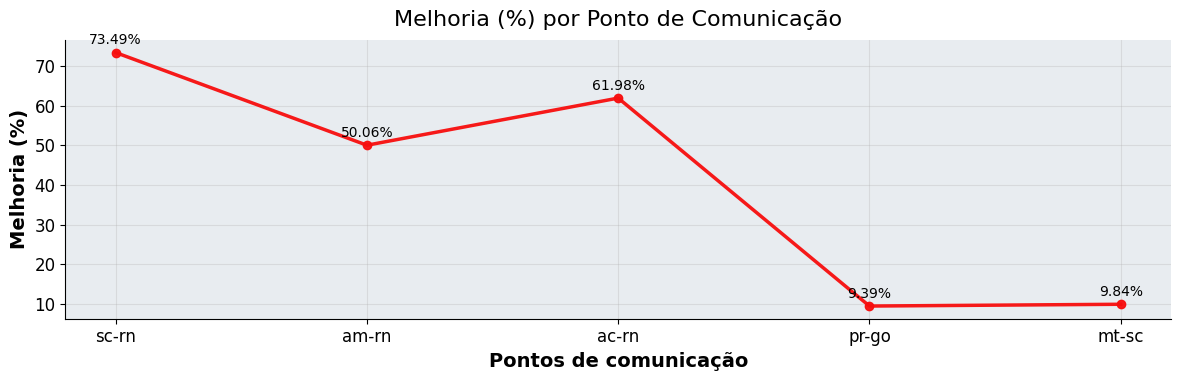

In [2]:
import matplotlib.pyplot as plt

# ============================================================================
# ESTILO PADRÃO
# ============================================================================
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# ============================================================================
# DADOS
# ============================================================================
points = ['sc-rn', 'am-rn', 'ac-rn', 'pr-go', 'mt-sc']
improvement = [73.49, 50.06, 61.98, 9.39, 9.84]

# ============================================================================
# GRÁFICO MAIS RETANGULAR (horizontal)
# ============================================================================
def plot_improvement_by_link():
    fig, ax = plt.subplots(figsize=(12, 4))  # 🔥 MAIS LARGO E BAIXO

    ax.plot(
        points,
        improvement,
        marker='o',
        linestyle='-',
        linewidth=2.5,
        markersize=6,
        color="#f70d0d",
        alpha=0.95
    )

    # Anotações menores (pra não poluir)
    for x, y in zip(points, improvement):
        ax.annotate(
            f'{y:.2f}%',
            xy=(x, y),
            xytext=(0, 6),
            textcoords='offset points',
            ha='center',
            fontsize=10
        )

    ax.set_title('Melhoria (%) por Ponto de Comunicação', pad=10)
    ax.set_xlabel('Pontos de comunicação', fontweight='bold')
    ax.set_ylabel('Melhoria (%)', fontweight='bold')

    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#e8ecf0')

    # Remove bordas superiores/direitas (fica mais clean)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('fig_improvement_links_wide.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('fig_improvement_links_wide.png', dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    plot_improvement_by_link()